In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
from Levenshtein import distance, jaro_winkler
from pylcs import lcs_sequence_length
import time
import matplotlib.pyplot as plt
import random
import numpy as np
import math
import sys
from urllib.parse import urlparse
from multiprocessing import Pool, cpu_count
import joblib
import os

sys.path.append("../..")
from ml.pipeline import normalised_levenshtein, normalised_lcs

# Remove the rank column from csv


In [ ]:

# try:
#     df = pd.read_csv("../data/top_10mil_domains.csv", sep=",")
#     # df.drop(columns=["Rank"], inplace=True)

#     df.to_csv("../data/top_10mil_domains.csv", index=False)

#     print("file cleaned successfully")
# except Exception as e:
#     print(f"file clean failed ({e})")

file cleaned successfully


# Split top 10 million domains into smaller sizes


In [4]:
try:
    df = pd.read_csv("../data/top_10mil_domains.csv")
    df = df.iloc[:1000000]
    print(df.shape)
    df.to_csv("../data/top_1mil_domains.csv", index=False)

    print("file reduced successfully")
except Exception as e:
    print(f"file reducing failed ({e})")

(1000000, 2)
file reduced successfully


In [5]:
try:
    df = pd.read_csv("../data/top_1mil_domains.csv")
    df = df.iloc[:100000]
    print(df.shape)
    df.to_csv("../data/top_100k_domains.csv", index=False)

    print("file reduced successfully")
except Exception as e:
    print(f"file reducing failed ({e})")

(100000, 2)
file reduced successfully


In [6]:
try:
    df = pd.read_csv("../data/top_100k_domains.csv")
    df = df.iloc[:10000]
    print(df.shape)
    df.to_csv("../data/top_10k_domains.csv", index=False)

    print("file reduced successfully")
except Exception as e:
    print(f"file reducing failed ({e})")

(10000, 2)
file reduced successfully


In [2]:
#  Where 1 is identical and 0 is different.
def normalised_levenshtein(a, b):
    return 1 - distance(a, b) / max(len(a), len(b))

In [1]:
#  Where 1 is identical and 0 is different.
def normalised_jaro_winkler(a, b):
    return jaro_winkler(a, b)

In [9]:
#  Where 1 is identical and 0 is different.
def normalised_lowest_common_sequence(a, b):
    return (2 * lcs_sequence_length(a, b)) / (len(a) + len(b))

# Comparing time using different sized whitelists


In [ ]:
comparison_types = ["levenshtein", "jaro winkler", "lowest common sequence"]
sizes = ["top_10k_domains", "top_100k_domains", "top_1mil_domains"]
string_lens = [5, 10, 20, 40]
all_plot_data = {}

for comparison_type in comparison_types:
    print(f"Working on {comparison_type}")
    if comparison_type == "levenshtein":
        func = normalised_levenshtein
    elif comparison_type == "jaro winkler":
        func = normalised_jaro_winkler
    elif comparison_type == "lowest common sequence":
        func = normalised_lowest_common_sequence
    
    plot_data = pd.DataFrame(index=sizes, columns=string_lens, dtype=float)
    for size in sizes:
        best_score = 0
        average_time = 0
        for string_len in string_lens:
            print(f"    Working on size {size} and string length {string_len}")
            all_times = []
            for i in range(3):
                start_time = time.time()
                df = pd.read_csv(f"../data/{size}.csv")
                rand_string = "".join([chr(random.randint(ord("a"), ord("z"))) for j in range(string_len)])
            
                for val in df["Domain"]:
                    try:
                        best_score = max(best_score, func(rand_string, val))
                    except Exception as e:
                        print(e)
                        print(rand_string)
                        print(type(rand_string))
                        print(val)
                        print(type(val))
                end_time = time.time()
                time_taken = (end_time - start_time)
                all_times.append(time_taken)

            plot_data.loc[size, string_len] = sum(all_times) / len(all_times)
    
    all_plot_data[comparison_type] = plot_data
        
    print(all_plot_data)
    
    

Working on levenshtein
    Working on size top_10k_domains and string length 5
    Working on size top_10k_domains and string length 10
    Working on size top_10k_domains and string length 20
    Working on size top_10k_domains and string length 40
    Working on size top_100k_domains and string length 5
    Working on size top_100k_domains and string length 10
    Working on size top_100k_domains and string length 20
    Working on size top_100k_domains and string length 40
    Working on size top_1mil_domains and string length 5
    Working on size top_1mil_domains and string length 10
    Working on size top_1mil_domains and string length 20
    Working on size top_1mil_domains and string length 40
    Working on size top_10mil_domains and string length 5
object of type 'float' has no len()
nwjfk
<class 'str'>
nan
<class 'float'>
object of type 'float' has no len()
nhftj
<class 'str'>
nan
<class 'float'>
object of type 'float' has no len()
kiiqq
<class 'str'>
nan
<class 'float'>
  

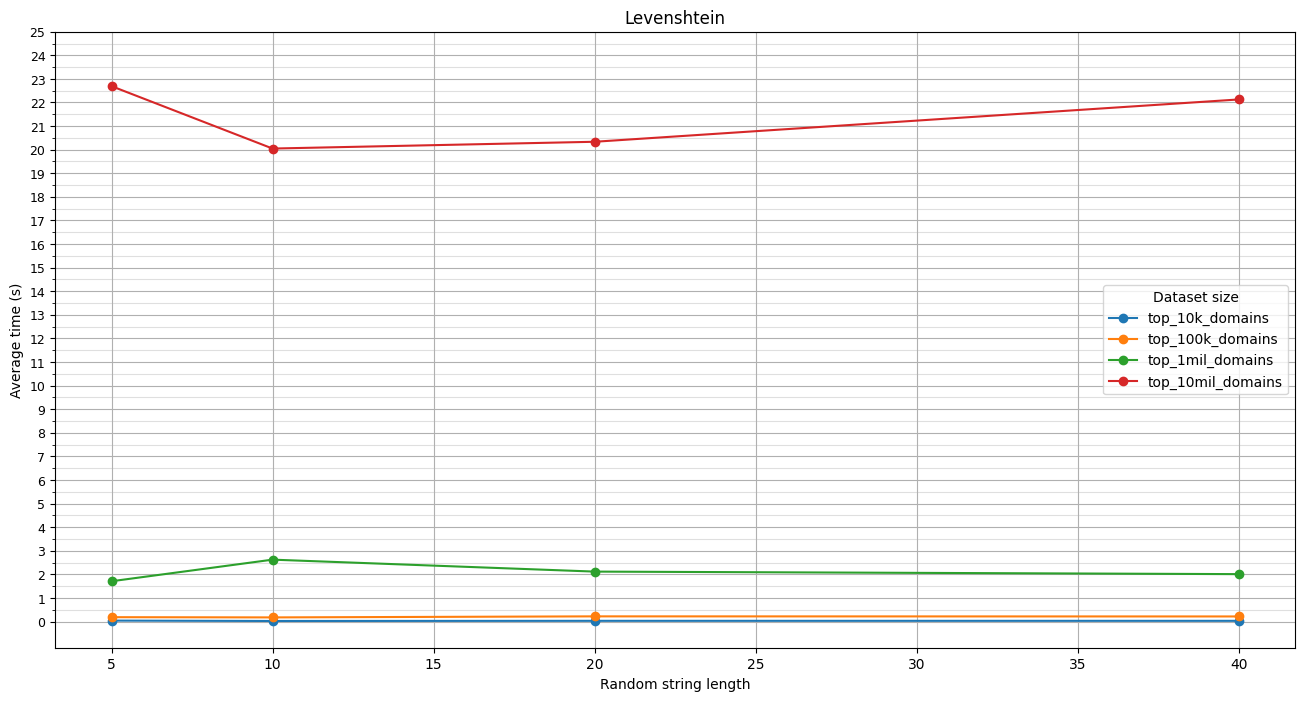

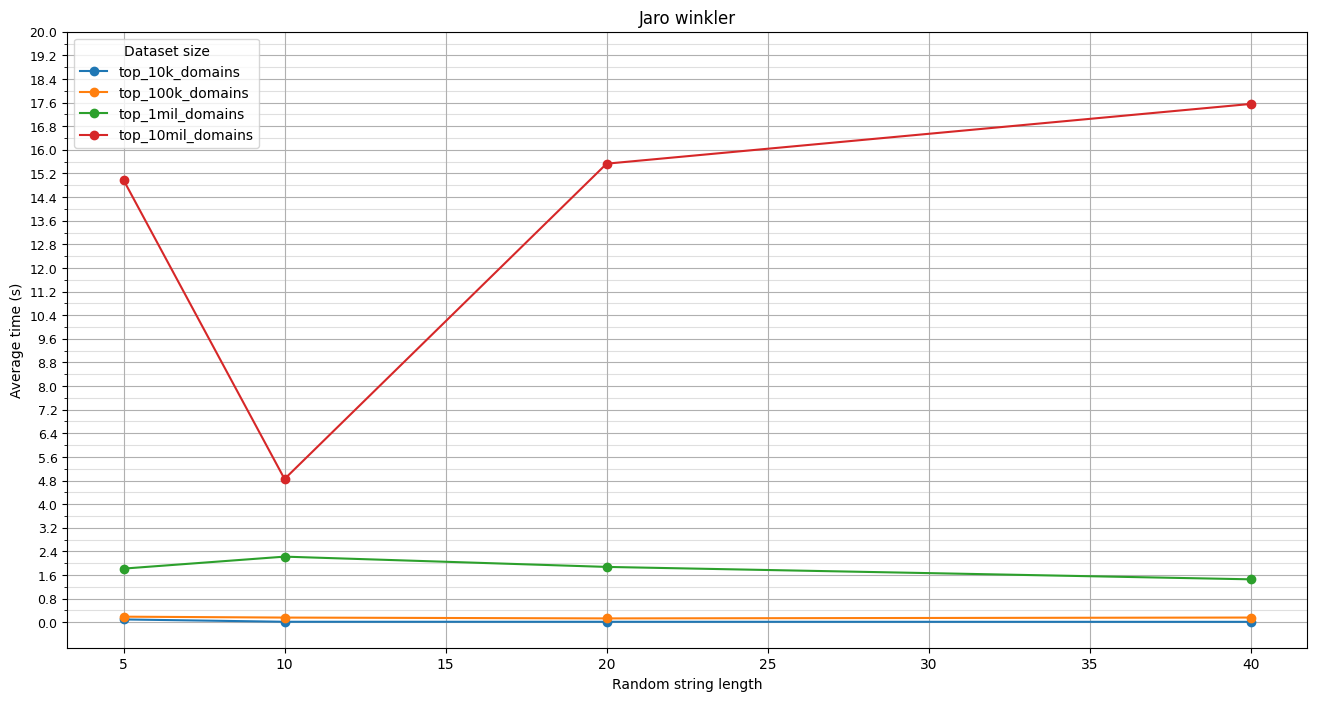

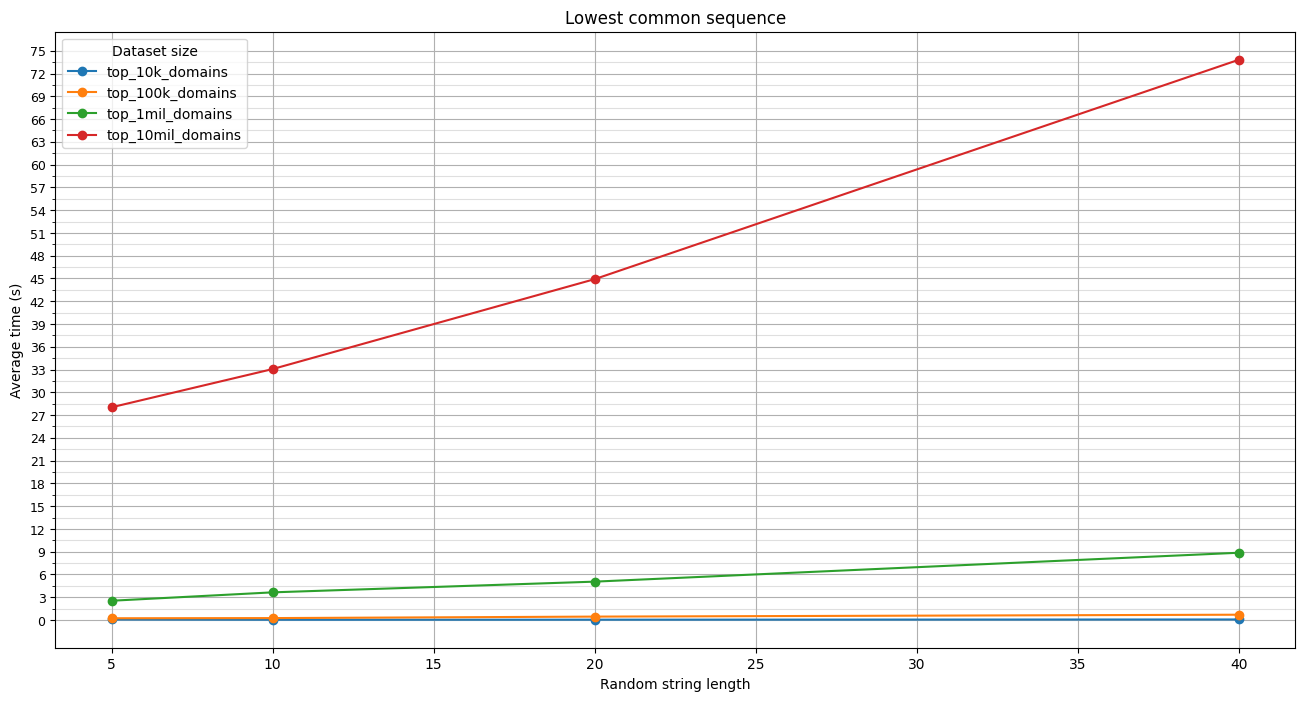

In [81]:
for comparison_type, plot_data in all_plot_data.items():
    plt.figure(figsize=(16, 8))

    for size in plot_data.index:
        plt.plot(plot_data.columns, plot_data.loc[size], marker="o", label=size)

    plt.title(comparison_type.capitalize())
    plt.xlabel("Random string length")
    plt.ylabel("Average time (s)")
    plt.yticks(np.linspace(0, 5 * round(plot_data.values.max() / 5), 26), fontsize=9)
    plt.gca().set_yticks(np.linspace(0, 5 * round(plot_data.values.max() / 5), 51), minor=True)
    plt.grid(True, which="major", linestyle="-", alpha=1)
    plt.grid(True, which="minor", linestyle="-", alpha=0.4)
    plt.legend(title="Dataset size")
    plt.savefig(f"../outputs/time_taken_{comparison_type.replace(' ', '_')}.png")
    plt.show()


# Adding Levenshtein, Jaro Winkler, and LCS to dataset


In [2]:
whitelist_path: str = "../data/top_100k_domains.csv"

In [3]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)

        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

performance-optimised version of search_whitelist with reduced error handling


In [4]:
def search_whitelist(domain: str, whitelist: list, whitelist_set: set):
    whitelist_set = set(whitelist)
    if domain in whitelist_set:
        return {
            "Levenshtein": 1,
            "JaroWinkler": 1,
            "LCS": 1,
        }

    best_levenshtein = 0
    best_jaro_winkler = 0
    best_lcs = 0
    for whitelist_domain in whitelist:
        best_levenshtein = max(best_levenshtein, normalised_levenshtein(domain, whitelist_domain))
        best_jaro_winkler = max(best_jaro_winkler, jaro_winkler(domain, whitelist_domain))
        best_lcs = max(best_lcs, normalised_lcs(domain, whitelist_domain))

    return {
        "Levenshtein": round(best_levenshtein, 6),
        "JaroWinkler": round(best_jaro_winkler, 6),
        "LCS": round(best_lcs, 6),
    }

In [5]:
cols_to_drop = [
    "Domain",
    "TLD",
    "Title",
    "HasTitle",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "HasFavicon",
    "Robots",
    "IsResponsive",
    "NoOfURLRedirect",
    "NoOfSelfRedirect",
    "HasDescription",
    "NoOfPopup",
    "NoOfiFrame",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasPasswordField",
    "Bank",
    "Pay",
    "Crypto",
    "HasCopyrightInfo",
    "NoOfImage",
    "NoOfCSS",
    "NoOfJS",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "LineOfCode",
    "LargestLineLength"
]

clean_csv("../data/uci_phishing_url_dataset.csv", "../data/uci_phishing_url_dataset_new.csv", cols_to_drop)

file: "../data/uci_phishing_url_dataset.csv" cleaned successfully


True

Add score to columns


In [6]:
df = pd.read_csv("../data/uci_phishing_url_dataset_new.csv")

if "Levenshtein" not in df.columns.tolist():
    df.insert(4, "Levenshtein", 0)
if "JaroWinkler" not in df.columns.tolist():
    df.insert(5, "JaroWinkler", 0)
if "LCS" not in df.columns.tolist():
    df.insert(6, "LCS", 0)

df.to_csv("../data/uci_phishing_url_dataset_new.csv", index=False)

In [7]:
df = pd.read_csv("../data/uci_phishing_url_dataset_new.csv")
whitelist_df = pd.read_csv(whitelist_path)
whitelist = whitelist_df["Domain"].tolist()
whitelist_set = set(whitelist)

Single process code


In [8]:
# cache = {}
# scores = []
# for i, url in enumerate(df["URL"]):
#     if i % 100 == 0:
#         print(f"Processing {i}", end="\r")
    
#     # not using preprocessor class to speed up search
#     domain = urlparse(url).netloc.split(":")[0]
#     domain = domain.removeprefix("www.")

#     score = search_whitelist(domain, whitelist, whitelist_set)
#     cache[domain] = score
#     print(score)
#     scores.append(cache[domain])

Multi-process code


In [9]:
def search_whitelist_unpack(args):
    return search_whitelist(*args)

In [ ]:
TEMP_FILE = "../data/tmp_scores_file.joblib"
urls = df["URL"].tolist()
domains = [urlparse(url).netloc.split(":")[0].removeprefix("www.") for url in urls]

scores = []
if os.path.exists(TEMP_FILE):
    scores = joblib.load(TEMP_FILE)

start_index = len(scores)
domains = domains[start_index:]

with Pool(processes=cpu_count()) as pool:
    tasks = ((domain, whitelist, whitelist_set) for domain in domains)
    for i, result in enumerate(pool.imap(search_whitelist_unpack, tasks)):
        if i % 100 == 0:
            print(f"Processed {start_index + i}", end="\r")

        scores.append(result)
        if len(scores) % 1000 == 0:
            joblib.dump(scores, TEMP_FILE)

print()

In [11]:
joblib.dump(scores, TEMP_FILE)
scores_df = pd.DataFrame(scores)
print(scores_df.head(10))

   Levenshtein  JaroWinkler       LCS
0     0.700000     0.890420  0.750000
1     1.000000     1.000000  1.000000
2     0.722222     0.873504  0.812500
3     0.866667     0.931746  0.896552
4     0.681818     0.863876  0.731707
5     1.000000     1.000000  1.000000
6     1.000000     1.000000  1.000000
7     0.666667     0.900000  0.769231
8     0.611111     0.795185  0.727273
9     1.000000     1.000000  1.000000


Separate code so scores_df runs once


In [12]:
df[scores_df.columns] = scores_df

df.to_csv("../data/uci_phishing_url_dataset_new.csv", index=False)